# 05 — Explainability (SHAP)

Two questions this notebook answers:
1. **Global**: across the whole test set, which features does the model rely on most?
2. **Faithfulness**: are SHAP's explanations actually describing what the model does, or just plausible-looking noise? (next section — deletion test)

This notebook re-derives the exact held-out test set from notebook 04 (same `random_state=42` split) so SHAP runs on the same ~1,900 rows the 0.83 macro F1 was measured on — not training data, not the 21-row demo sample.


In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("../data/processed/koi_cleaned.csv")
print("Shape:", df.shape)

Shape: (9564, 106)


In [3]:
# Rebuild X, y exactly as notebook 04 did, so the columns match what
# the saved model expects.
X = df.drop(columns=["koi_disposition"])
y = df["koi_disposition"]

text_cols = X.select_dtypes(exclude="number").columns.tolist()
X = X.drop(columns=text_cols)

print("Features:", X.shape)

Features: (9564, 99)


In [4]:
# Same split as notebook 04 — same random_state means the SAME rows land
# in X_test here as they did there. This is what makes SHAP results
# trustworthy: we're explaining the model on the exact data its 0.83
# macro F1 was measured on, not a different random sample.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Test set:", X_test.shape)


Test set: (1913, 99)


In [5]:
bundle = joblib.load("../models/exoplanet_model_bundle.joblib")
model = bundle["model"]
label_encoder = bundle["label_encoder"]
feature_columns = bundle["feature_columns"]

# Sanity check: column order must match exactly what the model trained
# on, or predictions silently come out wrong.
assert list(X_test.columns) == feature_columns, "Column mismatch — check notebook 03/04 for changes."
print("Columns match. Model expects", len(feature_columns), "features.")

Columns match. Model expects 99 features.


In [6]:
# The real test: do we get back the SAME 0.83 macro F1 notebook 04
# reported? If this doesn't match, the split or preprocessing drifted
# somewhere, and everything downstream (SHAP, faithfulness) would be
# explaining the wrong data.
y_pred = label_encoder.inverse_transform(model.predict(X_test))
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

     CANDIDATE       0.70      0.64      0.66       396
     CONFIRMED       0.90      0.91      0.90       549
FALSE POSITIVE       0.90      0.92      0.91       968

      accuracy                           0.86      1913
     macro avg       0.83      0.82      0.83      1913
  weighted avg       0.86      0.86      0.86      1913



## Global feature importance

The app already explains one prediction at a time. This section asks the broader question: across the whole test set, what does the model lean on overall?

In [7]:
# TreeExplainer computes exact Shapley values for tree ensembles in
# polynomial time (not factorial-time brute force) by exploiting tree
# structure — same approach app.py uses for one row, run here across
# the whole test set.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
# (n_test_rows, n_features, n_classes)

SHAP values shape: (1913, 99, 3)


In [8]:
# Global importance = average MAGNITUDE of impact per feature, averaged
# across every test row AND every class. A feature can matter a lot for
# one class without mattering for the others, so averaging across
# classes gives one overall "how much does this feature drive
# predictions" score.
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
importance = pd.Series(mean_abs_shap, index=feature_columns).sort_values(ascending=False)
importance.head(15)

koi_max_mult_ev      0.365734
koi_dikco_msky       0.365152
koi_prad             0.312113
koi_count            0.264890
koi_dicco_msky       0.262303
koi_smet_err2        0.235286
koi_model_snr        0.196560
koi_dor              0.137891
koi_fwm_srao         0.137485
koi_fwm_stat_sig     0.134479
koi_fwm_sdeco        0.127265
koi_fwm_sdec         0.121975
koi_srho_err1        0.118350
koi_period           0.115916
koi_duration_err1    0.114403
dtype: float32

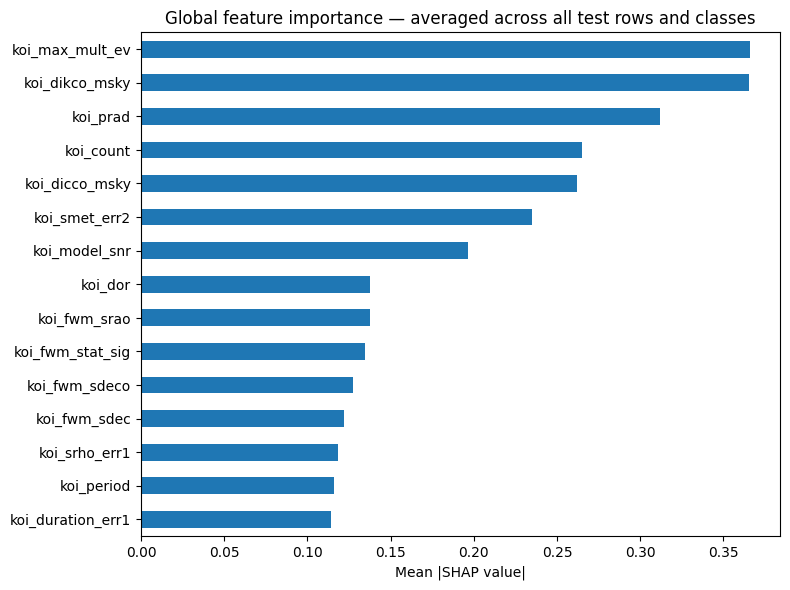

In [9]:
plt.figure(figsize=(8, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Mean |SHAP value|")
plt.title("Global feature importance — averaged across all test rows and classes")
plt.tight_layout()
plt.show()

## Faithfulness validation (deletion test)

A SHAP chart looking plausible isn't proof it reflects what the model actually does. This test checks: if we delete the features SHAP says matter most for a prediction, does the model's confidence in that prediction actually drop more than if we delete random features? If yes, the explanations are measuring something real.

In [10]:
# How many top features to "delete" (replace with an uninformative value)
# per row.
TOP_K = 5
rng = np.random.default_rng(42)

# "Uninformative" stand-in value: the TRAINING set's median for each
# feature. Using TRAIN medians (not test) keeps test-set statistics out
# of the evaluation itself.
train_medians = X_train.median().values

# Each row's model-predicted class — this is the prediction we're
# testing the explanation OF.
pred_encoded = model.predict(X_test)
baseline_proba_all = model.predict_proba(X_test)
baseline_proba = baseline_proba_all[np.arange(len(X_test)), pred_encoded]

# For each row, which features did SHAP say mattered most for ITS
# predicted class?
abs_shap_for_pred = np.abs(shap_values[np.arange(len(X_test)), :, pred_encoded])
shap_top_idx = np.argsort(-abs_shap_for_pred, axis=1)[:, :TOP_K]

In [11]:
# SHAP-deletion version: each row's top-K SHAP features replaced with
# the training median.
X_shap_deleted = X_test.values.copy()
for i in range(len(X_test)):
    X_shap_deleted[i, shap_top_idx[i]] = train_medians[shap_top_idx[i]]

# Random-deletion version — the control group. Same number of features
# deleted per row, chosen randomly instead of by SHAP rank.
n_features = X_test.shape[1]
random_top_idx = np.array([
    rng.choice(n_features, size=TOP_K, replace=False)
    for _ in range(len(X_test))
])
X_random_deleted = X_test.values.copy()
for i in range(len(X_test)):
    X_random_deleted[i, random_top_idx[i]] = train_medians[random_top_idx[i]]

In [12]:
# Re-predict on both modified versions — two batched calls total, not
# one per row.
shap_deleted_proba = model.predict_proba(X_shap_deleted)[np.arange(len(X_test)), pred_encoded]
random_deleted_proba = model.predict_proba(X_random_deleted)[np.arange(len(X_test)), pred_encoded]

# Drop in confidence for the model's OWN predicted class. Bigger drop =
# those features mattered more to the model's actual decision.
shap_drop = baseline_proba - shap_deleted_proba
random_drop = baseline_proba - random_deleted_proba

print(f"Mean confidence drop — SHAP top-{TOP_K} features removed: {shap_drop.mean():.4f}")
print(f"Mean confidence drop — {TOP_K} random features removed:   {random_drop.mean():.4f}")

win_rate = (shap_drop > random_drop).mean()
print(f"SHAP-targeted deletion beat random deletion on {win_rate:.1%} of rows.")

Mean confidence drop — SHAP top-5 features removed: 0.2173
Mean confidence drop — 5 random features removed:   0.0144
SHAP-targeted deletion beat random deletion on 92.4% of rows.


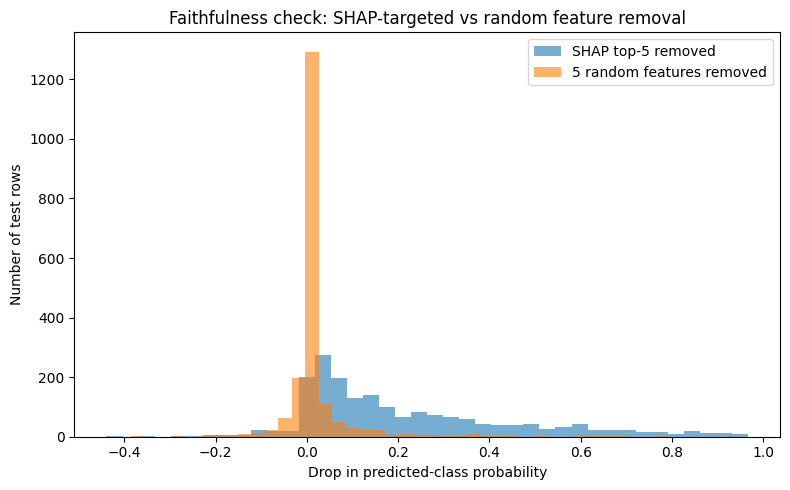

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(shap_drop, bins=40, alpha=0.6, label=f"SHAP top-{TOP_K} removed")
plt.hist(random_drop, bins=40, alpha=0.6, label=f"{TOP_K} random features removed")
plt.xlabel("Drop in predicted-class probability")
plt.ylabel("Number of test rows")
plt.title("Faithfulness check: SHAP-targeted vs random feature removal")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook answered two questions about the model's explanations: what does it rely on overall, and can those explanations be trusted?

**Global feature importance.** Averaged across the full ~1,900-row test set and all three classes, the model leans most heavily on `koi_max_mult_ev` (multiple-event transit signal strength), `koi_dikco_msky` and `koi_dicco_msky` (centroid offset), `koi_prad` (planet radius), and `koi_count` (number of KOIs cataloged for the host star). The top driver being a signal-strength metric makes physical sense — separating a real periodic transit from noise is the core of this classification task.

**A leakage note worth repeating from notebook 04:** the centroid-offset features (`koi_dikco_msky`, `koi_dicco_msky`) rank in the global top 5 here too, independently confirmed by SHAP rather than just Random Forest's `feature_importances_`. These sit near the leakage boundary flagged earlier, since they're closely related to the `koi_fpflag_co` flag dropped in notebook 03. Worth treating with the same caution.

**Faithfulness validation (deletion test).** To check whether SHAP's explanations reflect what the model actually does — not just plausible-looking attribution — each test row's top-5 SHAP-ranked features were replaced with their training-set median, and the drop in the model's confidence in its own predicted class was measured, compared against deleting 5 random features instead.

- Mean confidence drop, SHAP top-5 removed: **0.2173**
- Mean confidence drop, 5 random features removed: **0.0144**
- SHAP-targeted deletion beat random deletion on **92.4%%** of test rows.

The distribution backs this up visually: random-feature deletion barely moves confidence for most rows (a sharp spike near zero), while SHAP-targeted deletion produces a much wider spread with a long tail of large confidence drops. A meaningful share of rows show little change even under SHAP-targeted deletion — consistent with predictions backed by many corroborating features rather than one small decisive set, not a failure of the explanation.

**Conclusion.** The SHAP explanations used throughout this project — both the per-prediction bar chart in the Streamlit app and the global ranking above — are not just plausible-looking output. Removing the features they flag as important measurably and disproportionately damages the model's own confidence, compared to removing features at random. That is quantitative evidence the explanations are faithful to the model's actual decision-making, not decorative.